In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.db import connect
import matplotlib as mpl
mpl.rcParams["axes3d.mouserotationstyle"] = "azel"


In [2]:
filepath_db = r"data.db"

positions_list = []
symbols_list = []
numbers = []

with connect(filepath_db) as db:
    for row in db.select():
        atoms = row.toatoms()
        positions_list.append(atoms.get_positions())
        symbols_list = atoms.get_chemical_symbols()
        numbers = atoms.get_atomic_numbers()

positions_list = np.array([np.asarray(p, dtype=float) for p in positions_list])

print(positions_list.shape)
print(symbols_list)
print(numbers)

(1000, 9, 3)
['C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']
[6 6 8 1 1 1 1 1 1]


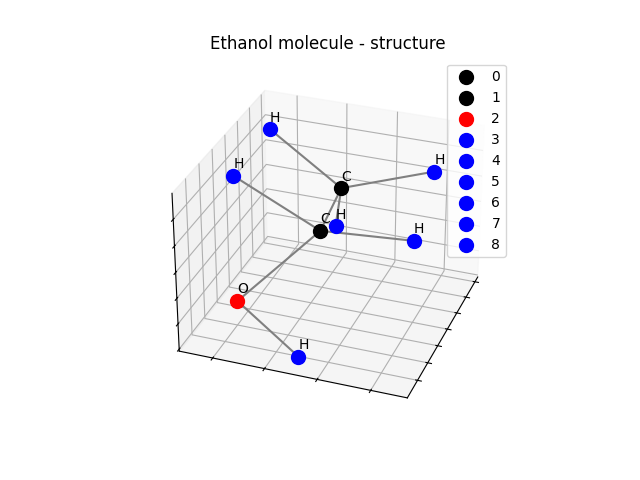

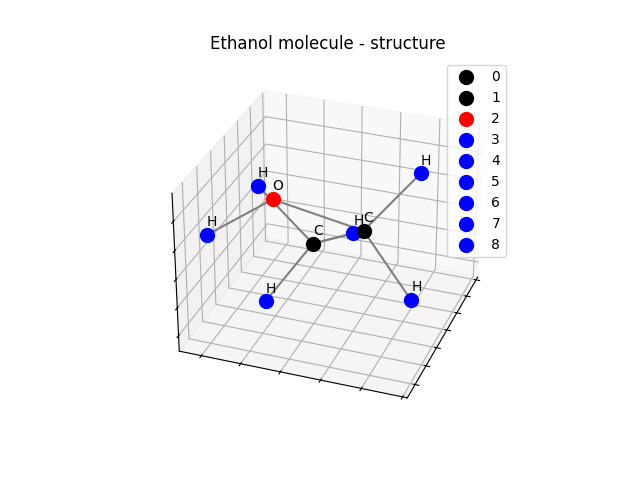

In [3]:
%matplotlib widget

def plot_atom(positions, numbers, title=""):
    colors = {6: "black", 8: "red", 1: "blue"}
    colors = [colors[n] for n in numbers]
    charges = {6: "C", 8: "O", 1: "H"}

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # draw the bond between atom (0, 2) and (2, 8)
    for i, j in [(0, 2), (2, 8), (0, 1), (0, 3), (0, 4), (1, 7), (1, 5), (1, 6)]:
        x = [positions[i][0], positions[j][0]]
        y = [positions[i][1], positions[j][1]]
        z = [positions[i][2], positions[j][2]]
        ax.plot(x, y, z, c="gray")

    for i, (x, y, z) in enumerate(positions):
        ax.scatter(x, y, z, c=colors[i], label=i, s=100)
        ax.text(
            x, y, z + 0.15, f"{charges[numbers[i]]}", color="black"
        )  # Shift the label slightly above the point

    # remove the axis
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

    if title != "":
        plt.title(title)

    # rotate
    ax.view_init(elev=30, azim=20)

    plt.legend()
    plt.show()
    
plot_atom(positions_list[0], numbers, title="Ethanol molecule - structure")
plot_atom(positions_list[-1], numbers, title="Ethanol molecule - structure")